# LAB | Ensemble Methods

**Load the data**

In this challenge, we will be working with the same Spaceship Titanic data, like the previous Lab. The data can be found here:

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv

Metadata

https://github.com/data-bootcamp-v4/data/blob/main/spaceship_titanic.md

In this Lab, you should try different ensemble methods in order to see if can obtain a better model than before. In order to do a fair comparison, you should perform the same feature scaling, engineering applied in previous Lab.

In [100]:
#Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import  fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor,AdaBoostRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error


In [101]:
spaceship = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/spaceship_titanic.csv")
spaceship.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


Now perform the same as before:
- Feature Scaling
- Feature Selection


## Feature Scaling

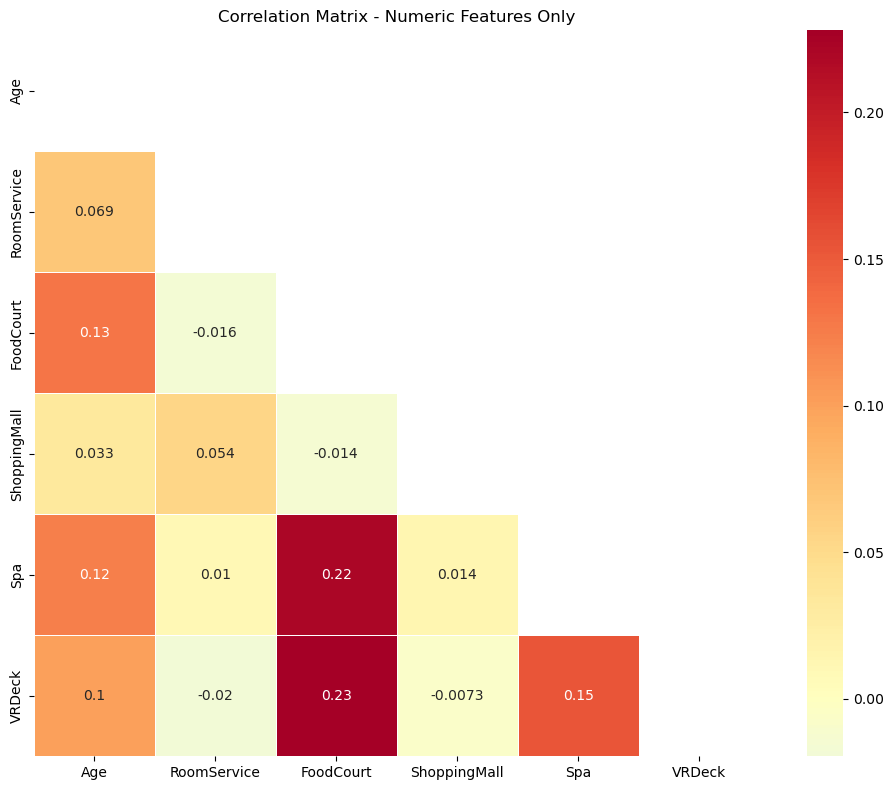

In [102]:


# Method 1: Only numeric columns
numeric_cols = spaceship.select_dtypes(include=[np.number]).columns
corr_numeric = spaceship[numeric_cols].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
mask = np.zeros_like(corr_numeric, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_numeric, 
           mask=mask, 
           annot=True, 
           cmap='RdYlBu_r', 
           center=0,
           square=True, 
           linewidths=0.5)

plt.title('Correlation Matrix - Numeric Features Only')
plt.tight_layout()
plt.show()

# Feature Selection

In [103]:

from sklearn.feature_selection import SelectKBest, chi2

# Prepare features (X) and target variable (y)
X = spaceship[['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']]
y = spaceship['Transported']

# Apply SelectKBest to select top 3 features
selector = SelectKBest(score_func=chi2, k=3)
X_new = selector.fit_transform(X.fillna(0), y)  # Filled missing values with 0 for simplicity

# Print selected feature names
selected_features = X.columns[selector.get_support()]
print("Selected features:", selected_features)

Selected features: Index(['RoomService', 'Spa', 'VRDeck'], dtype='object')


**Perform Train Test Split**

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encoded categorical variables
spaceship_encoded = spaceship.copy()

categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
for col in categorical_cols:
    if col in spaceship_encoded.columns:
        le = LabelEncoder()
        spaceship_encoded[col] = le.fit_transform(spaceship_encoded[col].astype(str))

# Defined features and target
numeric_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
all_features = numeric_features + categorical_cols

X = spaceship_encoded[all_features]
y = spaceship_encoded['Transported']

# Handled missing values
X = X.fillna(X.median())

# Encoded target if it's boolean/string
if y.dtype == 'object':
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)

# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (6954, 10)
Test set size: (1739, 10)


In [105]:
X_train

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet,CryoSleep,Destination,VIP
3600,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2,0
1262,17.0,0.0,0.0,0.0,0.0,0.0,0,1,2,0
8612,35.0,0.0,0.0,0.0,0.0,0.0,0,2,1,0
5075,26.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0
4758,13.0,0.0,0.0,60.0,1.0,5147.0,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...
4087,43.0,0.0,1947.0,0.0,0.0,1651.0,1,0,2,0
4406,38.0,183.0,203.0,0.0,110.0,374.0,0,0,2,0
7111,45.0,1.0,7.0,56.0,613.0,0.0,0,0,1,0
426,24.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0


In [106]:
X_test

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet,CryoSleep,Destination,VIP
3586,34.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0
7173,4.0,0.0,0.0,0.0,0.0,0.0,0,1,2,0
8559,25.0,410.0,32.0,14.0,1239.0,10.0,2,0,2,0
6528,12.0,0.0,0.0,0.0,0.0,0.0,2,0,2,2
7934,66.0,0.0,1828.0,1.0,1873.0,45.0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...
3749,33.0,0.0,0.0,0.0,0.0,0.0,2,1,2,0
1637,15.0,1336.0,108.0,0.0,0.0,0.0,0,0,2,0
5820,14.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0
5757,26.0,104.0,0.0,0.0,280.0,216.0,0,0,1,0


In [107]:
y_train

3600     True
1262     True
8612    False
5075     True
4758    False
        ...  
4087     True
4406    False
7111     True
426      True
7925     True
Name: Transported, Length: 6954, dtype: bool

In [108]:
y_test

3586     True
7173    False
8559    False
6528     True
7934    False
        ...  
3749     True
1637    False
5820     True
5757    False
4135     True
Name: Transported, Length: 1739, dtype: bool

**Model Selection** - now you will try to apply different ensemble methods in order to get a better model

- Bagging and Pasting

In [109]:
# Train your BaggingRegressor
bagging_reg = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
bagging_reg.fit(X_train, y_train)

# Predict on test set
y_pred_test_bag = bagging_reg.predict(X_test)

# Evaluation
print(f"MAE {mean_absolute_error(y_test, y_pred_test_bag): .2f}")
print(f"MSE {mean_squared_error(y_test, y_pred_test_bag): .2f}")
print(f"RMSE {np.sqrt(mean_squared_error(y_test, y_pred_test_bag)): .2f}")  # use np.sqrt for RMSE
print(f"R2 score {bagging_reg.score(X_test, y_test): .2f}")

MAE  0.29
MSE  0.14
RMSE  0.38
R2 score  0.42


- Random Forests

In [110]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)

Random Forest Accuracy: 0.7964

Classification Report:
              precision    recall  f1-score   support

       False       0.81      0.77      0.79       863
        True       0.78      0.82      0.80       876

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739


Feature Importance:
        feature  importance
7     CryoSleep    0.202823
4           Spa    0.166313
1   RoomService    0.125660
5        VRDeck    0.123281
2     FoodCourt    0.113202
3  ShoppingMall    0.088857
6    HomePlanet    0.083183
0           Age    0.075575
8   Destination    0.015982
9           VIP    0.005124


- Gradient Boosting

In [111]:
from sklearn.ensemble import GradientBoostingClassifier  # <--- FIX: add this import!

# Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, classification_report

gb_accuracy = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7993

Classification Report:
              precision    recall  f1-score   support

       False       0.82      0.76      0.79       863
        True       0.78      0.83      0.81       876

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



- Adaptive Boosting

In [112]:
from sklearn.ensemble import AdaBoostClassifier

# AdaBoost Classifier
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# Train the model
ada_model.fit(X_train, y_train)

# Make predictions
y_pred_ada = ada_model.predict(X_test)

# Evaluate
ada_accuracy = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Accuracy: {ada_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.7625

Classification Report:
              precision    recall  f1-score   support

       False       0.74      0.80      0.77       863
        True       0.79      0.72      0.75       876

    accuracy                           0.76      1739
   macro avg       0.76      0.76      0.76      1739
weighted avg       0.76      0.76      0.76      1739



Which model is the best and why?

In [113]:
# Compare all models
results = pd.DataFrame({
    'Model': ['Bagging', 'Random Forest', 'Gradient Boosting', 'AdaBoost'],
    'Accuracy': [bagging_accuracy, rf_accuracy, gb_accuracy, ada_accuracy]
}).sort_values('Accuracy', ascending=False)

print("\n=== Model Comparison ===")
print(results)

# Determine the best model
best_model_name = results.iloc[0]['Model']
best_accuracy = results.iloc[0]['Accuracy']

print(f"\n=== Best Model ===")
print(f"The best model is {best_model_name} with accuracy: {best_accuracy:.4f}")

# Cross-validation for more robust evaluation
from sklearn.model_selection import cross_val_score

models = {
    'Bagging': bagging_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'AdaBoost': ada_model
}

print("\n=== Cross-Validation Scores (5-fold) ===")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


=== Model Comparison ===
               Model  Accuracy
2  Gradient Boosting  0.799310
1      Random Forest  0.796435
0            Bagging  0.792409
3           AdaBoost  0.762507

=== Best Model ===
The best model is Gradient Boosting with accuracy: 0.7993

=== Cross-Validation Scores (5-fold) ===
Bagging: 0.7890 (+/- 0.0086)
Random Forest: 0.7939 (+/- 0.0064)
Gradient Boosting: 0.7883 (+/- 0.0116)
AdaBoost: 0.7748 (+/- 0.0077)
